# Generate gold labels

My primary job here is to generate QA accuracy for the generated data for subject-entity related questions.

In [1]:
import pandas as pd
from datasets import load_dataset
from ast import literal_eval

In [2]:
def qa_accuracy(model_name):
    def _generation(model_name, question, generation):
        if model_name in ["llama2_7B", "llama2_13B", "vicuna_7B", "vicuna_13B"]:
            generation = generation.replace(f"<s> {question}", "").strip()
            generation = generation.replace(f"</s>", "").strip()
        elif model_name in ["gpt2_xl", "pythia_6B", "pythia_12B"]:
            generation = generation.replace(f"{question}", "").strip()
        return generation

    df = load_dataset(f"kokolamba/keen_popqa_gpt2xl_generations")
    df = df["train"].to_pandas()
    df["deterministic_generation"] = df.apply(lambda row: _generation(model_name, row["question"], row["deterministic_generation"]), axis=1)

    questions = load_dataset("dhgottesman/keen_estimating_knowledge_in_llms", data_files="popqa_questions.csv")
    questions = questions["train"].to_pandas()
    questions["possible_answers"] = questions["possible_answers"].apply(lambda x: literal_eval(x))
    questions = questions.rename(columns={"subj": "subject"})

    df = df.merge(questions, on="question").dropna()

    def label_generation(generation, answers):
        for answer in answers:
            if answer.lower() in generation.lower():
                return 3
        for hedged_answer in ["nobody knows", "I'm sorry", "I can't seem to find the answer", "you help me", "anyone help me", "I'm not sure", "I don't know"]:
            if hedged_answer.lower() in generation.lower():
                return 2
        # if generation is an empty, this is taking to be a hedged answer
        if generation == "":
                return 2
        return 1

    def binary_label(label, class_label):
        return 1 if label == class_label else 0

    df["generation_label"] = df.apply(lambda row: label_generation(row["deterministic_generation"], row["possible_answers"]), axis=1)
    # Multiple answers for each question, if one of them is correct then mark the question as correct.
    idx = df.groupby(['subject', 's_uri', 'prop'])["generation_label"].idxmax()
    df = df.loc[idx]

    # We want to compute correct, hedged, mistake accuracy.
    df["correct"] = df["generation_label"].apply(lambda x: binary_label(x, 3))
    df["hedge"] = df["generation_label"].apply(lambda x: binary_label(x, 2))
    df["mistake"] = df["generation_label"].apply(lambda x: binary_label(x, 1))

    result_df = df.groupby(['subject', 's_uri', "label"]).agg(
        total_examples=('generation_label', 'count'),
        accuracy=('correct', 'mean')
        # hedged_frac=('hedge', 'mean'),
        # mistake_frac=('mistake', 'mean')
    ).reset_index()

    result_df = result_df[result_df["total_examples"] > 1]
    return result_df # ["subject", "accuracy", "total_examples"]

In [3]:
model_name = "gpt2_xl"
result_df = qa_accuracy(model_name)

README.md:   0%|          | 0.00/332 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/2.02M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/19203 [00:00<?, ? examples/s]

popqa_questions.csv: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [4]:
result_df.columns

Index(['subject', 's_uri', 'label', 'total_examples', 'accuracy'], dtype='object')

In [5]:
# Let's obtain row where subject == Night Train to Lisbon
result_df[result_df["subject"] == "Night Train to Lisbon"]

,subject,s_uri,label,total_examples,accuracy
2376,Night Train to Lisbon,http://www.wikidata.org/entity/Q5177219,head,7,0.285714


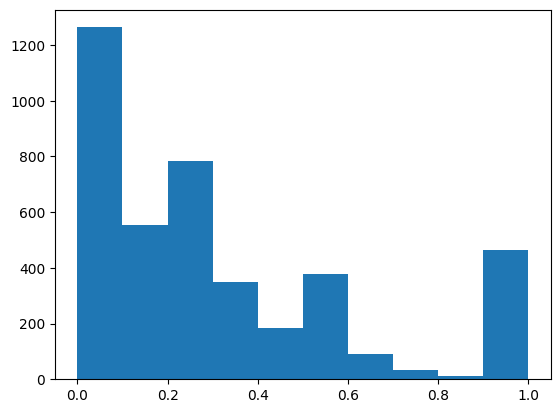

In [34]:
# Please plot histogram of accuracy for result_df including examples == 1
import matplotlib.pyplot as plt

plt.hist(result_df["accuracy"], bins=10)
plt.show()

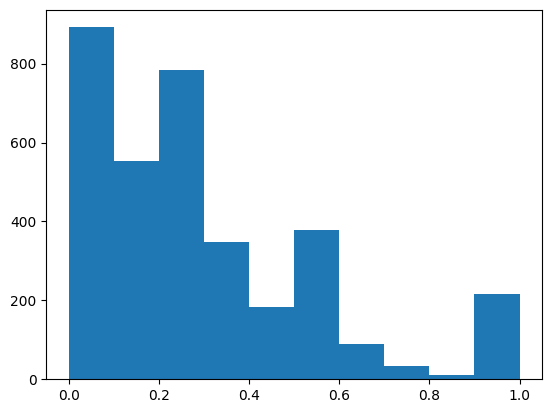

In [40]:
# Histogram of accuracy after removing rows with total_examples == 1

plt.hist(result_df["accuracy"], bins=10)
plt.show()

# Generate internal/hidden state representation

Our job here is to extract hidden state of subject entities from later layers of a gpt2-xl.

- Set up model and tokenizer
- Set up prompt template
- Load dataset with subject and accuracy data.
- Feed per-subject prompt to model and extract hidden representation for specific layers
- Do MinMax scaling of individual representation in each layer and then average them.
-

In [6]:
# @title Setup model and tokenizer
import torch
import transformers
import re

def set_requires_grad(requires_grad, *models):
  for model in models:
    if isinstance(model, torch.nn.Module):
      for param in model.parameters():
        param.requires_grad = requires_grad
    elif isinstance(model, (torch.nn.Parameter, torch.Tensor)):
      model.requires_grad = requires_grad
    else:
      assert False, "unknown type %r" % type(model)


class GPTModelAndTokenizer:
  """An object to hold a GPT-style language model and tokenizer."""

  def __init__(
      self,
      model_name=None,
      model=None,
      tokenizer=None,
      low_cpu_mem_usage=False,
      torch_dtype=None,
      ):
    if tokenizer is None:
      assert model_name is not None
      tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
    if model is None:
      assert model_name is not None
      model = transformers.AutoModelForCausalLM.from_pretrained(
          model_name, low_cpu_mem_usage=low_cpu_mem_usage,
          torch_dtype=torch_dtype
          )
      set_requires_grad(False, model)
    self.tokenizer = tokenizer
    self.model = model
    self.layer_names = [
        n
        for n, _ in model.named_modules()
        if (re.match(r"^(transformer|gpt_neox)\.(h|layers)\.\d+$", n))
    ]
    self.num_layers = len(self.layer_names)
    self.vocabulary_projection_function = lambda x, layer: self.model.lm_head(self.model.transformer.ln_f(x)) if layer < self.num_layers else self.model.lm_head(x)
    self.mlp_hidden_size = self.model.config.n_embd * 4
    print(self.mlp_hidden_size)
    print(self.model.config)

  def __repr__(self):
    """String representation of this class.
    """
    return (
        f"ModelAndTokenizer(model: {type(self.model).__name__} "
        f"[{self.num_layers} layers], "
        f"tokenizer: {type(self.tokenizer).__name__})"
        )


In [7]:
# @title Setup prompt template

def document_prefix(subject):
    return f"This document describes {subject}"

- Daniella's qa_dataset obtained with `Llama` has 3475 rows of data of hidden dataset and accuracy.
- my qa_dataset obtained with `gpt2-xl` has 3491 rows of data of hidden dataset and accuracy
- Size of hidden state is 4096. This is gotten by averaging hidden states at given 3 layers of the model.
- All subjects data for gpt2_xl is 3491
- Original keen data has 2224, 556, 695 train, val and test subjects data respectively.
- After merging with all `gpt2_xl` data, there are 2155, 550, 695 train, val and test subjects data respectively.

TODO

- [x] Want to check out the shape of hidden_state of multi-token subject entity such as "Night Train to Lisbon"
- [ ] Checkout how layernorm works as separate from MinMax Scaler?

In [21]:
# @title Install required dependencies
# !pip -q install huggingface_hub joblib scikit-learn transformers torch

In [8]:
# @title Load gpt2-xl
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mt = GPTModelAndTokenizer(model_name="gpt2-xl") # Corrected model name
mt.tokenizer.pad_token = mt.tokenizer.eos_token # Set pad_token to eos_token
mt.model = mt.model.to(device)
mt.model.eval()

print("num_layers:\n", mt.num_layers)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

6400
GPT2Config {
  "activation_function": "gelu_new",
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "dtype": "float32",
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 1600,
  "n_head": 25,
  "n_inner": null,
  "n_layer": 48,
  "n_positions": 1024,
  "output_past": true,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "transformers_version": "4.57.3",
  "use_cache": true,
  "vocab_size": 50257
}

num_layers:
 48


In [10]:
from __future__ import annotations

from typing import Callable, Dict, List, Sequence
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm # Import tqdm


def document_prefix(subject: str) -> str:
    return f"This document describes {subject}"


@torch.no_grad()
def extract_hidden_states_per_layer(
    mt,
    train_subjects_df: pd.DataFrame,
    layers: Sequence[int],
    prompt_func: Callable[[str], str] = document_prefix,
    batch_size: int = 8,
    device: torch.device | None = None,
) -> Dict[int, np.ndarray]:
    """
    Returns:
      dict[layer_idx] -> X_layer of shape (N_train, d_model)
    where each row is the last-token hidden vector for the prompt built from that subject.

    Uses only unique train subjects.
    """
    if "subject" not in train_subjects_df.columns:
        raise ValueError("train_subjects_df must contain a 'subject' column")

    subjects = train_subjects_df["subject"].dropna().astype(str).unique().tolist()
    if len(subjects) == 0:
        raise ValueError("No subjects found in train_subjects_df['subject'].")

    if device is None:
        try:
            device = next(mt.model.parameters()).device
        except StopIteration:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    layers = list(layers)
    if not layers:
        raise ValueError("layers must be non-empty")

    # We'll accumulate vectors per layer into python lists, then stack at end
    per_layer_rows: Dict[int, List[np.ndarray]] = {layer: [] for layer in layers}

    tokenizer = mt.tokenizer
    model = mt.model

    for start in tqdm(range(0, len(subjects), batch_size), desc="Extracting hidden states"):
        batch_subjects = subjects[start : start + batch_size]
        prompts = [prompt_func(s) for s in batch_subjects]

        tok = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True).to(device)
        out = model(**tok, output_hidden_states=True)

        # last non-pad token per sequence
        attn = tok["attention_mask"]                 # (B, S)
        last_pos = (attn.sum(dim=1) - 1).long()      # (B,)

        for b_idx in range(len(batch_subjects)):
            pos = int(last_pos[b_idx].item())
            for layer in layers:
                vec = out.hidden_states[layer][b_idx, pos, :].detach().float().cpu().numpy()
                per_layer_rows[layer].append(vec)

    # Stack -> (N_train, d_model)
    X: Dict[int, np.ndarray] = {}
    for layer in layers:
        X[layer] = np.stack(per_layer_rows[layer], axis=0).astype(np.float32)

    return X

In [11]:
import pandas as pd
from huggingface_hub import hf_hub_download

train_subjects_df_path = hf_hub_download(
    repo_id="dhgottesman/keen_estimating_knowledge_in_llms",
    filename="popqa_train_subjects.csv",
    repo_type="dataset"
)

train_subjects_df = pd.read_csv(train_subjects_df_path)

popqa_train_subjects.csv: 0.00B [00:00, ?B/s]

In [12]:
# Extract hidden states by layer
num_layers = mt.num_layers
layers = range(int(0.75 * num_layers) - 3, int(0.75 * num_layers))
X_by_layer = extract_hidden_states_per_layer(mt, train_subjects_df, layers=layers, batch_size=16, device=device)

Extracting hidden states:   0%|          | 0/135 [00:00<?, ?it/s]

In [26]:
# 1:50pm

In [13]:
# @title Fit MinMaxScaler per layer save to .joblib

from sklearn.preprocessing import MinMaxScaler
import joblib
from datetime import datetime


def fit_minmax_scalers_per_layer(
    X_by_layer: dict[int, np.ndarray],
    layers: Sequence[int],
) -> list[MinMaxScaler]:
    """
    Fits one MinMaxScaler per layer on X_layer with shape (N_train, d_model).
    Returns scalers in the same order as `layers`.
    """
    scalers: list[MinMaxScaler] = []
    for layer in layers:
        X = X_by_layer[layer]  # (N_train, d_model)
        scaler = MinMaxScaler()  # feature-wise scaling across samples (TRAIN subjects)
        scaler.fit(X)
        scalers.append(scaler)
    return scalers

# Run minmax scaler per layer
scalers = fit_minmax_scalers_per_layer(X_by_layer, layers=layers)

artifact = {
    "repo_note": "MinMaxScalers fit on TRAIN subjects only",
    "model_name": "gpt2-xl",
    "layers": list(layers),
    "d_model": int(X_by_layer[layers[0]].shape[1]),
    "prompt_template": "This document describes {subject}",
    "scalers": scalers,
}

local_path = f"gpt2xl_keen_minmax_scalers.joblib"
joblib.dump(artifact, local_path)

print("Saved:", local_path)

Saved: gpt2xl_keen_minmax_scalers.joblib


In [14]:
import os
from google.colab import userdata

# Get the token from Colab secrets
colab_hf_token = userdata.get("HF_TOKEN")

# Set it as an environment variable for the Python process
if colab_hf_token:
    os.environ["HF_TOKEN"] = colab_hf_token
    print("HF_TOKEN successfully set as environment variable.")
else:
    raise RuntimeError("HF_TOKEN not found in Colab secrets. Please add it before running this cell.")


HF_TOKEN successfully set as environment variable.


In [15]:
import os
from huggingface_hub import HfApi
from google.colab import userdata

# Retrieve HF_TOKEN from Colab secrets
HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    raise RuntimeError("HF_TOKEN not found in env. Use export HF_TOKEN=.... Please add it.")

repo_id = "kokolamba/keen_popqa_gpt2xl_generations"

api = HfApi(token=HF_TOKEN)

path_in_repo = f"scalers/{os.path.basename(local_path)}"  # store under a scalers/ folder

api.upload_file(
    path_or_fileobj=local_path,
    path_in_repo=path_in_repo,
    repo_id=repo_id,
    repo_type="dataset",
    commit_message=f"Add per-layer MinMaxScalers (train-only) for GPT-2 XL: layers={layers}",
)

print("Uploaded to:", f"{repo_id}/{path_in_repo}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...een_minmax_scalers.joblib: 100%|##########| 97.5kB / 97.5kB            

Uploaded to: kokolamba/keen_popqa_gpt2xl_generations/scalers/gpt2xl_keen_minmax_scalers.joblib


In [16]:
# @title Delete .joblib file from huggingface dataset repo

# from huggingface_hub import HfApi
# import os

# HF_TOKEN = os.environ["HF_TOKEN"]  # must have write access
# api = HfApi(token=HF_TOKEN)

# if not HF_TOKEN:
#     raise RuntimeError("HF_TOKEN not found in env. Use export HF_TOKEN=.... Please add it.")

# repo_id = "kokolamba/keen_popqa_gpt2xl_generations"
# path_in_repo = f"scalers/{os.path.basename(local_path)}"

# api.delete_file(
#     repo_id=repo_id,
#     path_in_repo=path_in_repo,
#     repo_type="dataset",
#     commit_message=f"Delete {path_in_repo}",
# )

# print("Deleted:", f"{repo_id}/{path_in_repo}")
